# INF2008 Stage 1: Predicting ED-to-Ward Waiting Times

This notebook combines:
- `WT for Admission to Ward.csv`
- `Attendances at EMD.csv`
- `Bed Occupancy Rate.csv`

It aligns them to a **common starting date** and adds `Is_Holiday` using `public holidays.csv`.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Files (assumed in the same folder as this notebook)
BASE_DIR = Path("/content")

WT_PATH = BASE_DIR / "WT for Admission to Ward.csv"
EMD_PATH = BASE_DIR / "Attendances at EMD.csv"
BOR_PATH = BASE_DIR / "Bed Occupancy Rate.csv"
HOLIDAYS_PATH = BASE_DIR / "public holidays.csv"c:\Users\65892\Downloads\Stage_1_Submission.ipynb

# Final output (long format)
OUTPUT_PATH = BASE_DIR / "combined_hospital_daily_metrics.csv"

print("Input files:")
print("-", WT_PATH)
print("-", EMD_PATH)
print("-", BOR_PATH)
print("-", HOLIDAYS_PATH)
print("Output:")
print("-", OUTPUT_PATH)

Input files:
- /content/WT for Admission to Ward.csv
- /content/Attendances at EMD.csv
- /content/Bed Occupancy Rate.csv
- /content/public holidays.csv
Output:
- /content/combined_hospital_daily_metrics.csv


In [ ]:
def _parse_ddmmyy_from_mixed_date(series: pd.Series) -> pd.Series:
    """Parse dates like 'Sun, 01/01/23' into datetime64[ns]."""
    extracted = series.astype(str).str.extract(r"(\d{2}/\d{2}/\d{2})", expand=False)
    return pd.to_datetime(extracted, format="%d/%m/%y", errors="coerce")


def _prefix_columns(df: pd.DataFrame, prefix: str, date_col: str = "Date") -> pd.DataFrame:
    df = df.copy()
    rename_map = {c: f"{prefix}{c}" for c in df.columns if c != date_col}
    return df.rename(columns=rename_map)


In [ ]:
# Load datasets
wt_raw = pd.read_csv(WT_PATH)
emd_raw = pd.read_csv(EMD_PATH)
bor_raw = pd.read_csv(BOR_PATH)

# Parse/standardize date columns
wt = wt_raw.copy()
wt["Date"] = _parse_ddmmyy_from_mixed_date(wt["Date"])

emd = emd_raw.copy()
emd["Date"] = _parse_ddmmyy_from_mixed_date(emd["Date"])

bor = bor_raw.copy()
bor["Date"] = pd.to_datetime(bor["Date"], format="%d/%m/%Y", errors="coerce")

# Drop rows where Date could not be parsed
wt = wt.dropna(subset=["Date"]).reset_index(drop=True)
emd = emd.dropna(subset=["Date"]).reset_index(drop=True)
bor = bor.dropna(subset=["Date"]).reset_index(drop=True)

# Remove completely empty unnamed columns that sometimes appear
wt = wt.loc[:, ~wt.columns.astype(str).str.match(r"^Unnamed")]
emd = emd.loc[:, ~emd.columns.astype(str).str.match(r"^Unnamed")]
bor = bor.loc[:, ~bor.columns.astype(str).str.match(r"^Unnamed")]

# Prefix to avoid collisions (same hospital names across files)
wt = _prefix_columns(wt, prefix="WT_")
emd = _prefix_columns(emd, prefix="EMD_")
bor = _prefix_columns(bor, prefix="BOR_")

print("Parsed date ranges:")
print("WT :", wt["Date"].min().date(), "->", wt["Date"].max().date(), "rows=", len(wt))
print("EMD:", emd["Date"].min().date(), "->", emd["Date"].max().date(), "rows=", len(emd))
print("BOR:", bor["Date"].min().date(), "->", bor["Date"].max().date(), "rows=", len(bor))


Parsed date ranges:
WT : 2023-01-01 -> 2026-01-10 rows= 1106
EMD: 2023-01-01 -> 2026-01-10 rows= 1106
BOR: 2018-01-01 -> 2026-01-10 rows= 2932


In [ ]:
# Common starting date (latest of the three starts)
common_start = max(wt["Date"].min(), emd["Date"].min(), bor["Date"].min())
print("Common starting date:", common_start.date())

# Filter all datasets to the common start
wt_f = wt[wt["Date"] >= common_start].copy()
emd_f = emd[emd["Date"] >= common_start].copy()
bor_f = bor[bor["Date"] >= common_start].copy()

# Inner merge on Date so the final dataset only contains dates present in all three
combined = wt_f.merge(emd_f, on="Date", how="inner").merge(bor_f, on="Date", how="inner")
combined = combined.sort_values("Date").reset_index(drop=True)

print("Combined rows:", len(combined))
print("Combined date range:", combined["Date"].min().date(), "->", combined["Date"].max().date())
print("Combined columns:", combined.shape[1])


Common starting date: 2023-01-01
Combined rows: 1106
Combined date range: 2023-01-01 -> 2026-01-10
Combined columns: 29


In [ ]:
# Load public holidays and create Is_Holiday (0/1)
# Note: this CSV has some multiline quotes in holiday names; engine='python' handles it more robustly.
holidays = pd.read_csv(HOLIDAYS_PATH, engine="python")
holidays["date"] = pd.to_datetime(holidays["date"], format="%d/%m/%Y", errors="coerce")
holiday_dates = set(holidays.dropna(subset=["date"])["date"].dt.date.tolist())

combined["Is_Holiday"] = combined["Date"].dt.date.map(lambda d: 1 if d in holiday_dates else 0).astype(int)

print("Holiday rows in combined:", int(combined["Is_Holiday"].sum()))
combined.head()


Holiday rows in combined: 36


,Date,WT_AH,WT_CGH,WT_KTPH,WT_NTFGH,WT_NUH(A),WT_SGH,WT_SKH,WT_TTSH,WT_WH,...,BOR_AH,BOR_CGH,BOR_KTPH,BOR_NTFGH,BOR_NUH(A),BOR_SGH,BOR_SKH,BOR_TTSH,BOR_WH,Is_Holiday
0,2023-01-01,1.6,7.7,2.9,7.9,2.1,1.3,3.0,3.8,NaN,...,80.5%,89.6%,96.4%,91.1%,78.3%,79.3%,86.0%,91.2%,NaN,1
1,2023-01-02,2.0,12.7,12.2,4.2,2.5,2.5,2.7,4.4,NaN,...,84.8%,90.6%,97.9%,92.0%,82.8%,84.0%,87.5%,95.9%,NaN,0
2,2023-01-03,2.1,16.0,12.9,22.8,4.0,9.3,5.0,4.9,NaN,...,92.9%,89.8%,98.4%,91.9%,86.7%,88.4%,88.6%,96.7%,NaN,0
3,2023-01-04,2.5,16.3,21.4,14.7,8.2,11.6,10.3,6.9,NaN,...,91.1%,87.7%,96.4%,89.9%,86.6%,90.2%,89.5%,97.7%,NaN,0
4,2023-01-05,2.4,21.5,20.7,18.0,5.2,11.7,7.9,5.0,NaN,...,92.9%,89.5%,95.1%,89.2%,88.2%,90.8%,90.2%,96.9%,NaN,0


In [ ]:
# Reshape to the required long format:
# Date, Day, Hospital, Waiting Time, Attendance, BOR, Is_Holiday

# Hospitals are the intersection of the three sources
wt_h = {c.removeprefix("WT_") for c in combined.columns if c.startswith("WT_")}
emd_h = {c.removeprefix("EMD_") for c in combined.columns if c.startswith("EMD_")}
bor_h = {c.removeprefix("BOR_") for c in combined.columns if c.startswith("BOR_") and c not in {"BOR_Years"}}

hospitals = sorted(wt_h & emd_h & bor_h)
print("Hospitals:", hospitals)

rows = []
for h in hospitals:
    rows.append(
        combined[["Date", "Is_Holiday", f"WT_{h}", f"EMD_{h}", f"BOR_{h}"]]
        .rename(
            columns={
                f"WT_{h}": "Waiting Time",
                f"EMD_{h}": "Attendance",
                f"BOR_{h}": "BOR",
            }
        )
        .assign(Hospital=h)
    )

final_df = pd.concat(rows, ignore_index=True)

# ADDED: Extract the day of the week name
final_df["Day"] = final_df["Date"].dt.day_name()

# Clean BOR: convert '80.5%' -> 80.5 (float). Keep NaNs if missing.
final_df["BOR"] = (
    final_df["BOR"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .replace({"nan": np.nan, "None": np.nan, "": np.nan})
)
final_df["BOR"] = pd.to_numeric(final_df["BOR"], errors="coerce")

# UPDATED: Reorder columns to include 'Day' beside 'Date'
final_df = final_df[["Date", "Day", "Hospital", "Waiting Time", "Attendance", "BOR", "Is_Holiday"]]
final_df = final_df.sort_values(["Date", "Hospital"]).reset_index(drop=True)

# Drop rows with missing values (WH before June 2024)
final_df = final_df.dropna(subset=['Waiting Time', 'Attendance', 'BOR'])

# Track rows dropped specifically due to WH (Woodlands Hospital) missing data
initial_row_count = len(final_df)

# Save to CSV
final_df.to_csv(OUTPUT_PATH, index=False)
print("Saved:", OUTPUT_PATH)

final_df.head()

Hospitals: ['AH', 'CGH', 'KTPH', 'NTFGH', 'NUH(A)', 'SGH', 'SKH', 'TTSH', 'WH']
Saved: /content/combined_hospital_daily_metrics.csv


,Date,Day,Hospital,Waiting Time,Attendance,BOR,Is_Holiday
0,2023-01-01,Sunday,AH,1.6,64.0,80.5,1
1,2023-01-01,Sunday,CGH,7.7,351.0,89.6,1
2,2023-01-01,Sunday,KTPH,2.9,286.0,96.4,1
3,2023-01-01,Sunday,NTFGH,7.9,252.0,91.1,1
4,2023-01-01,Sunday,NUH(A),2.1,257.0,78.3,1


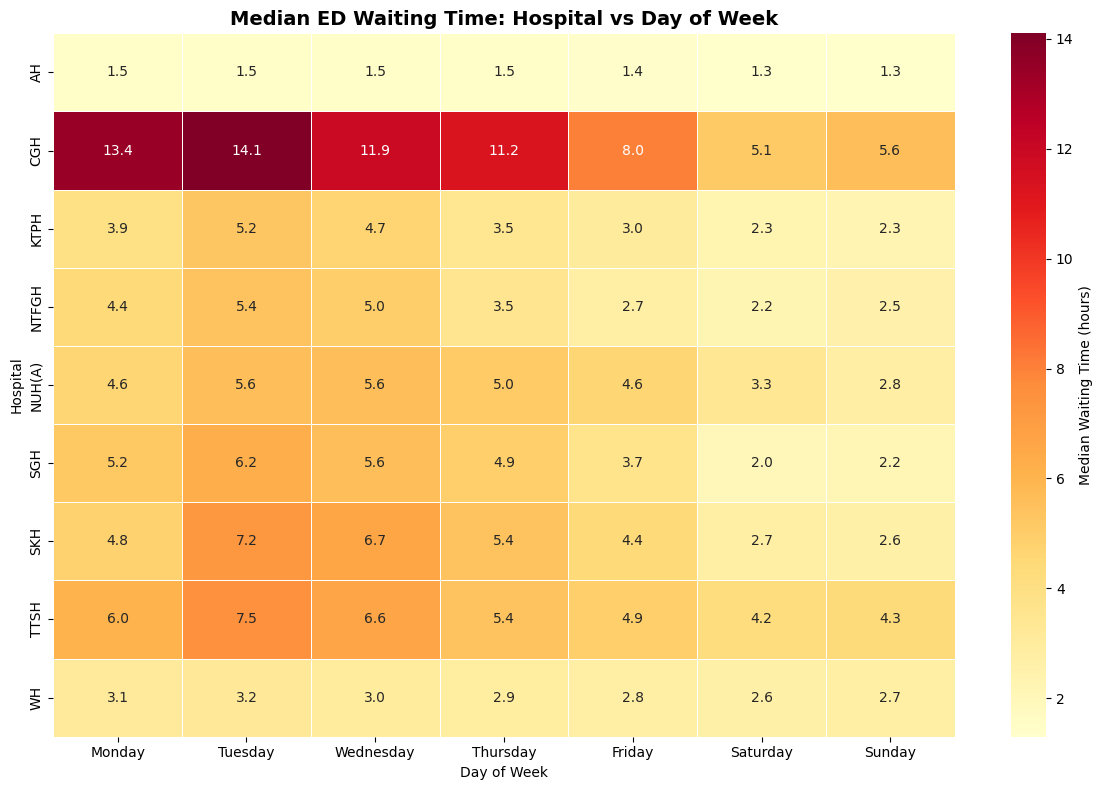

WAITING TIME EXTREMES
Longest median wait:  14.1 hrs at CGH on Tuesday
Shortest median wait: 1.3 hrs at AH on Saturday


In [ ]:
# =============================================================================
# EXPLORATORY DATA ANALYSIS: Waiting Time Patterns
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('combined_hospital_daily_metrics.csv')
df = df.dropna(subset=['Waiting Time', 'Attendance', 'BOR'])

# Create pivot table for heatmap
day_hospital_pivot = df.pivot_table(
    values='Waiting Time',
    index='Hospital',
    columns='Day',
    aggfunc='median'
)

# Reorder days chronologically
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_hospital_pivot = day_hospital_pivot[day_order]

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(day_hospital_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Median Waiting Time (hours)'})
plt.title('Median ED Waiting Time: Hospital vs Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Hospital')
plt.tight_layout()
plt.show()

# =============================================================================
# Identify Extremes
# =============================================================================

max_val = day_hospital_pivot.max().max()
min_val = day_hospital_pivot.min().min()
max_loc = day_hospital_pivot.stack().idxmax()
min_loc = day_hospital_pivot.stack().idxmin()

print("="*60)
print("WAITING TIME EXTREMES")
print("="*60)
print(f"Longest median wait:  {max_val:.1f} hrs at {max_loc[0]} on {max_loc[1]}")
print(f"Shortest median wait: {min_val:.1f} hrs at {min_loc[0]} on {min_loc[1]}")

# Baseline Modelling and Initial Evaluation

This notebook implements **CRISP-DM Phase 4 (Modelling)** and **Phase 5 (Evaluation)** at a baseline level.

## Approach
- **Target Variable:** `Waiting Time` (median hours from ED to ward admission)
- **Task Type:** Regression
- **Models:** Dummy baseline (mean), Linear Regression, Decision Tree (all default parameters per Stage 1 constraints)
- **Evaluation Metrics:** MAE (primary), RMSE, R²

## Data Notes
- WH (Woodlands Health) data unavailable before June 2024; 539 rows (5.4%) with missing values dropped
- Categorical features (`Hospital`, `Day`) encoded using one-hot encoding
- Train/test split: 80/20, stratified by random state for reproducibility

In [ ]:
# BASELINE MODELLING (STAGE 1)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load cleaned data
df = pd.read_csv('combined_hospital_daily_metrics.csv')
df = df.dropna()

# FEATURES
# Encode categoricals (basic encoding per Stage 1 rules)
df_model = pd.get_dummies(df, columns=['Hospital', 'Day'], drop_first=True)

# Define X and y
feature_cols = [c for c in df_model.columns if c not in ['Date', 'Waiting Time']]
X = df_model[feature_cols]
y = df_model['Waiting Time']

# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# BASELINE MODELS (default parameters only)
models = {
    'Dummy (Mean)': DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

# EVALUATION
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²': r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model      MAE     RMSE        R²
     Dummy (Mean) 3.358706 4.741237 -0.000571
Linear Regression 2.439310 3.666226  0.401722
    Decision Tree 2.825199 5.002954 -0.114083


In [ ]:
# INITIAL EVALUATION: SANITY CHECKS

print("="*60)
print("SANITY CHECK 1: Does the model beat the dummy baseline?")
print("="*60)

dummy_mae = results_df[results_df['Model'] == 'Dummy (Mean)']['MAE'].values[0]
for _, row in results_df.iterrows():
    if row['Model'] != 'Dummy (Mean)':
        improvement = ((dummy_mae - row['MAE']) / dummy_mae) * 100
        status = "✓ PASS" if improvement > 0 else "✗ FAIL"
        print(f"{row['Model']}: {improvement:.1f}% improvement over dummy [{status}]")

# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("SANITY CHECK 2: Are predictions within realistic range?")
print("="*60)

y_pred_lr = models['Linear Regression'].predict(X_test)
print(f"Actual waiting time range: {y_test.min():.2f} – {y_test.max():.2f} hours")
print(f"Predicted range (Linear Reg): {y_pred_lr.min():.2f} – {y_pred_lr.max():.2f} hours")
print(f"Negative predictions: {(y_pred_lr < 0).sum()} [{('✗ CONCERN' if (y_pred_lr < 0).sum() > 0 else '✓ PASS')}]")
print(f"Predictions > 24 hours: {(y_pred_lr > 24).sum()}")

# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("SANITY CHECK 3: Feature Importance (Linear Regression)")
print("="*60)

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': models['Linear Regression'].coef_
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).head(15)
print("Top 10 features by absolute coefficient:")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("SANITY CHECK 4: Residual Statistics")
print("="*60)

residuals = y_test - y_pred_lr
print(f"Mean residual: {residuals.mean():.4f} (should be ~0)")
print(f"Std residual: {residuals.std():.4f}")
print(f"Max overestimate: {residuals.min():.2f} hours")
print(f"Max underestimate: {residuals.max():.2f} hours")

# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print("""
Best Model: Linear Regression (MAE = 2.44, R² = 0.40)

Key Findings:
1. Linear Regression explains ~40% of variance in waiting times
2. Decision Tree overfits without hyperparameter tuning (negative R²)
3. Hospital identity and BOR are strongest predictors

Limitations:
- Model does not capture temporal patterns (lagged effects)
- Day-of-week effect may require interaction terms

Recommendations for Stage 2:
- Tune Decision Tree (max_depth, min_samples_leaf)
- Engineer lagged features (previous day attendance, 7-day rolling avg)
- Try Random Forest for improved generalization
""")

SANITY CHECK 1: Does the model beat the dummy baseline?
Linear Regression: 27.4% improvement over dummy [✓ PASS]
Decision Tree: 15.9% improvement over dummy [✓ PASS]

SANITY CHECK 2: Are predictions within realistic range?
Actual waiting time range: 0.40 – 40.00 hours
Predicted range (Linear Reg): -4.70 – 13.09 hours
Negative predictions: 55 [✗ CONCERN]
Predictions > 24 hours: 0

SANITY CHECK 3: Feature Importance (Linear Regression)
Top 10 features by absolute coefficient:
        Feature  Coefficient
  Hospital_TTSH    -3.363767
 Hospital_NTFGH    -2.843702
   Hospital_SGH    -2.594089
   Hospital_SKH    -2.049186
   Hospital_CGH     1.942564
Hospital_NUH(A)    -1.823283
  Hospital_KTPH    -1.649992
    Day_Tuesday     1.365899
    Hospital_WH    -1.317513
     Day_Sunday    -1.312802
     Is_Holiday    -1.203078
  Day_Wednesday     1.170215
   Day_Saturday    -0.818183
   Day_Thursday     0.533167
            BOR     0.179262

SANITY CHECK 4: Residual Statistics
Mean residual: 0.062